<a href="https://colab.research.google.com/github/ManoGit-99/Microgrid-Enrgy-System-with-LSTM-PPO-algorithms/blob/main/LSTM_Implementation_Russ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *LSTM для микросетей энергоснабжения в Западной Африке с учетом возобновляемых и традиционных источников энергии*

## *Полная схема реализации*

### Модуль 1:  Установка необходимых библиотек для реализации LSTM для микросетей

In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Проверка доступности GPU
print(f"Версия TensorFlow: {tf.__version__}")
print(f"GPU доступен: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Настройки для графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Версия TensorFlow: 2.19.0
GPU доступен: False


## *Модуль 2: Генерация данных для Западной Африки с учетом солнечной энергии, ветра и дизельных генераторов*

In [ ]:
def generate_microgrid_data(days=365, samples_per_day=24):
    """
    Генерация реалистичных данных микросетей для Западной Африки
    """
    total_samples = days * samples_per_day
    t = np.linspace(0, days, total_samples)

    # Климатические параметры для Западной Африки
    # Солнечная радиация (ярко выраженный дневной цикл)
    solar_radiation = (
        np.sin(2 * np.pi * t / 24) *  # Суточный цикл
        (1 + 0.3 * np.sin(2 * np.pi * t / 365)) *  # Сезонные колебания
        np.maximum(0, np.sin(np.pi * (t % 24) / 12))  # Ночью нет солнца
    ) + 0.1 * np.random.normal(size=total_samples)

    # Скорость ветра (характерные для региона)
    wind_speed = (
        3 + 2 * np.sin(2 * np.pi * t / 24 + np.pi/4) +  # Суточные колебания
        1.5 * np.sin(2 * np.pi * t / 365) +  # Сезонные изменения
        0.5 * np.random.normal(size=total_samples)
    )

    # Температура (типичная для Западной Африки)
    temperature = (
        28 + 8 * np.sin(2 * np.pi * t / 24) +  # Суточные колебания
        5 * np.sin(2 * np.pi * t / 365 - np.pi/2) +  # Сезонные изменения
        0.5 * np.random.normal(size=total_samples)
    )

    # Потребление энергии (социальные и экономические паттерны)
    # Утренний и вечерний пики потребления
    daily_pattern = (
        0.7 * np.sin(2 * np.pi * (t % 24) / 24 - np.pi/2) +
        0.3 * np.sin(4 * np.pi * (t % 24) / 24 - np.pi/2)
    )

    energy_consumption = (
        50 + 30 * daily_pattern +  # Базовое потребление + суточные паттерны
        10 * np.sin(2 * np.pi * t / 7) +  # Недельные циклы
        5 * np.maximum(0, temperature - 30) +  # Влияние температуры на кондиционирование
        2 * np.random.normal(size=total_samples)
    )

    # Генерация солнечной энергии (зависит от радиации)
    solar_generation = (
        solar_radiation * 100 *  # Эффективность солнечных панелей
        (1 - 0.005 * (temperature - 25))  # Снижение эффективности при высокой температуре
    )

    # Генерация ветровой энергии
    wind_generation = (
        np.maximum(0, wind_speed - 3)**2 * 5 *  # Кубическая зависимость от скорости ветра
        (wind_speed <= 25)  # Отключение при слишком сильном ветре
    )

    # Дизельная генерация (компенсирует дефицит)
    energy_deficit = np.maximum(0, energy_consumption - solar_generation - wind_generation)
    diesel_generation = np.minimum(50, energy_deficit * 1.1)  # Максимальная мощность 50 кВт

    # Напряжение в сети
    grid_voltage = (
        230 +  # Номинальное напряжение
        10 * np.sin(2 * np.pi * t / 24) +  # Суточные колебания
        5 * (energy_consumption - np.mean(energy_consumption)) / np.std(energy_consumption) +  # Влияние нагрузки
        1 * np.random.normal(size=total_samples)
    )

    # Создание DataFrame
    data = pd.DataFrame({
        'timestamp': pd.date_range(start='2023-01-01', periods=total_samples, freq='H'),
        'solar_radiation': solar_radiation,
        'wind_speed': wind_speed,
        'temperature': temperature,
        'energy_consumption': energy_consumption,
        'solar_generation': solar_generation,
        'wind_generation': wind_generation,
        'diesel_generation': diesel_generation,
        'grid_voltage': grid_voltage
    })

    return data


In [ ]:
def create_microgrid_features(data):
    """
    Создание дополнительных признаков для микросетей
    """
    df = data.copy()

    # Временные признаки
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Технические признаки
    df['total_renewable_generation'] = df['solar_generation'] + df['wind_generation']
    df['energy_balance'] = df['total_renewable_generation'] - df['energy_consumption']
    df['renewable_penetration'] = df['total_renewable_generation'] / (df['energy_consumption'] + 1e-5)
    df['diesel_utilization'] = df['diesel_generation'] / (df['energy_consumption'] + 1e-5)

    # Скользящие средние
    df['consumption_ma_6h'] = df['energy_consumption'].rolling(window=6, min_periods=1).mean()
    df['solar_ma_24h'] = df['solar_generation'].rolling(window=24, min_periods=1).mean()

    return df

In [ ]:
# Генерация и подготовка данных
print("Генерация данных микросетей для Западной Африки...")
microgrid_data = generate_microgrid_data(days=180, samples_per_day=24)
microgrid_data = create_microgrid_features(microgrid_data)

# Заполнение пропущенных значений
microgrid_data = microgrid_data.fillna(method='bfill')

print("Сгенерированные данные:")
print(microgrid_data.head())
print(f"\nРазмерность данных: {microgrid_data.shape}")

Генерация данных микросетей для Западной Африки...
Сгенерированные данные:
            timestamp  solar_radiation  wind_speed  temperature  \
0 2023-01-01 00:00:00         0.041520    4.337681    22.958479   
1 2023-01-01 01:00:00         0.016831    4.242106    23.847396   
2 2023-01-01 02:00:00         0.033273    4.113951    23.104974   
3 2023-01-01 03:00:00         0.148004    4.167301    23.340840   
4 2023-01-01 04:00:00        -0.027829    4.166034    22.746618   

   energy_consumption  solar_generation  wind_generation  diesel_generation  \
0           19.335832          4.194363         8.946951           6.813969   
1           21.452202          1.692782         7.714131          13.249818   
2           23.376698          3.358871         6.204429          15.194738   
3           19.998191         14.923198         6.812957           0.000000   
4           15.405502         -2.814206         6.798182          12.563679   

   grid_voltage  hour  day_of_week  month  is_w

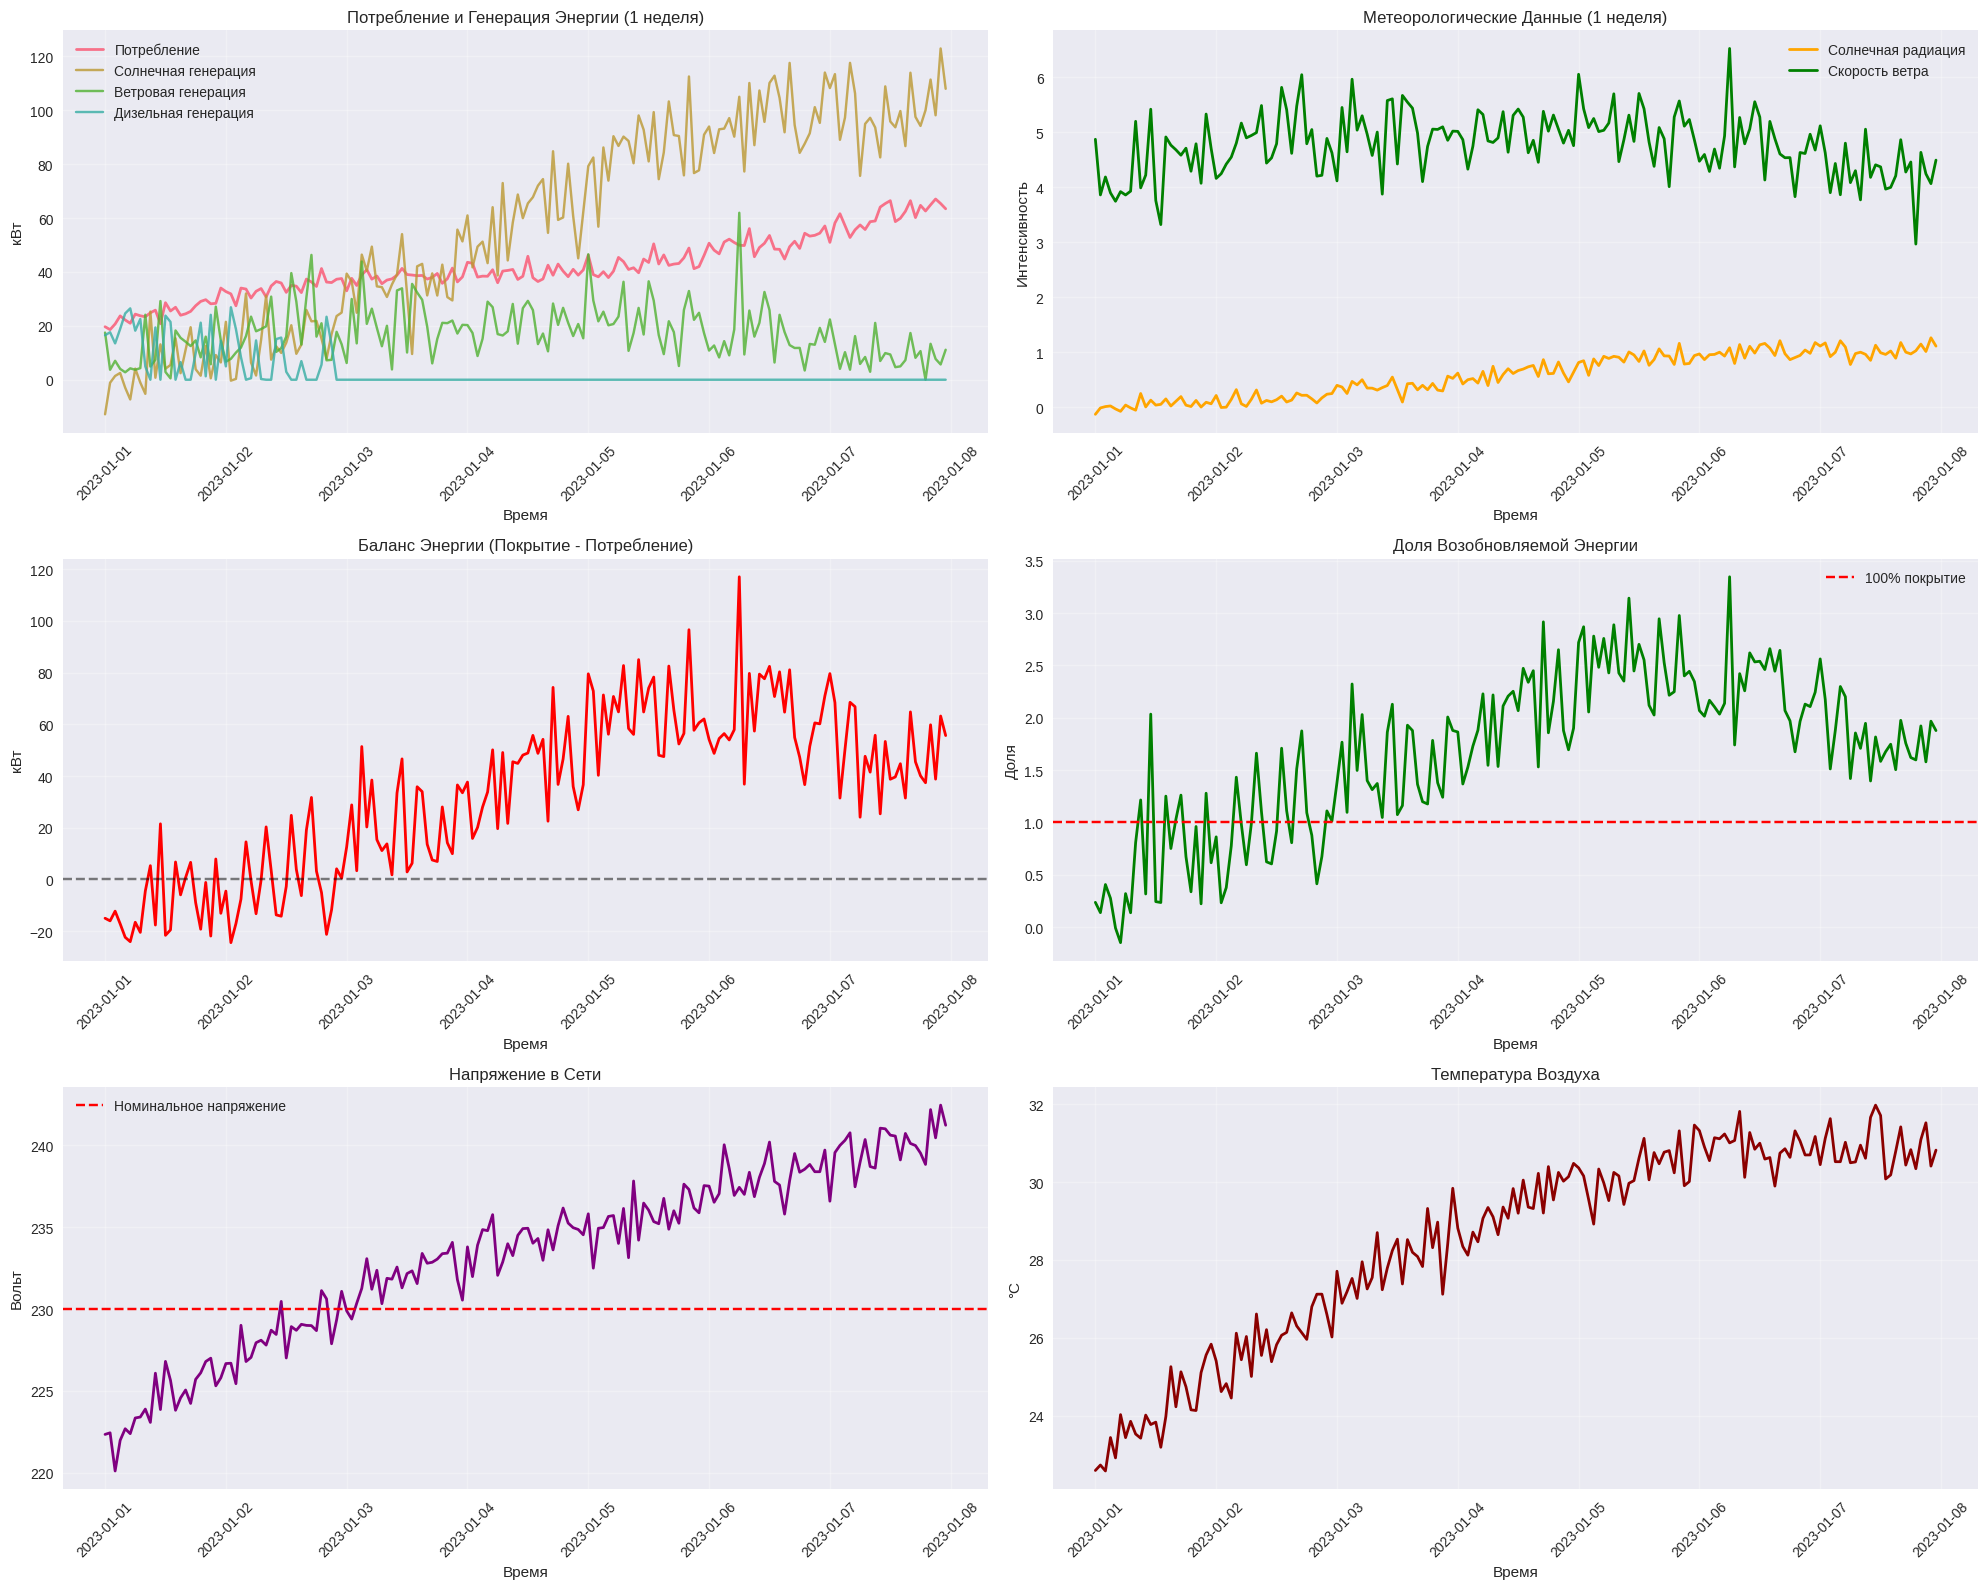

In [ ]:
# Визуализация данных микросетей
plt.figure(figsize=(20, 16))

# 1. Потребление и генерация
plt.subplot(3, 2, 1)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['energy_consumption'][:168],
         label='Потребление', linewidth=2)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['solar_generation'][:168],
         label='Солнечная генерация', alpha=0.8)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['wind_generation'][:168],
         label='Ветровая генерация', alpha=0.8)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['diesel_generation'][:168],
         label='Дизельная генерация', alpha=0.8)
plt.title('Потребление и Генерация Энергии (1 неделя)')
plt.xlabel('Время')
plt.ylabel('кВт')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2. Возобновляемые источники
plt.subplot(3, 2, 2)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['solar_radiation'][:168],
         label='Солнечная радиация', color='orange', linewidth=2)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['wind_speed'][:168],
         label='Скорость ветра', color='green', linewidth=2)
plt.title('Метеорологические Данные (1 неделя)')
plt.xlabel('Время')
plt.ylabel('Интенсивность')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 3. Баланс энергии
plt.subplot(3, 2, 3)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['energy_balance'][:168],
         color='red', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Баланс Энергии (Покрытие - Потребление)')
plt.xlabel('Время')
plt.ylabel('кВт')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 4. Проникновение возобновляемой энергии
plt.subplot(3, 2, 4)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['renewable_penetration'][:168],
         color='green', linewidth=2)
plt.axhline(y=1, color='red', linestyle='--', label='100% покрытие')
plt.title('Доля Возобновляемой Энергии')
plt.xlabel('Время')
plt.ylabel('Доля')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 5. Напряжение в сети
plt.subplot(3, 2, 5)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['grid_voltage'][:168],
         color='purple', linewidth=2)
plt.axhline(y=230, color='red', linestyle='--', label='Номинальное напряжение')
plt.title('Напряжение в Сети')
plt.xlabel('Время')
plt.ylabel('Вольт')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 6. Температура
plt.subplot(3, 2, 6)
plt.plot(microgrid_data['timestamp'][:168], microgrid_data['temperature'][:168],
         color='darkred', linewidth=2)
plt.title('Температура Воздуха')
plt.xlabel('Время')
plt.ylabel('°C')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

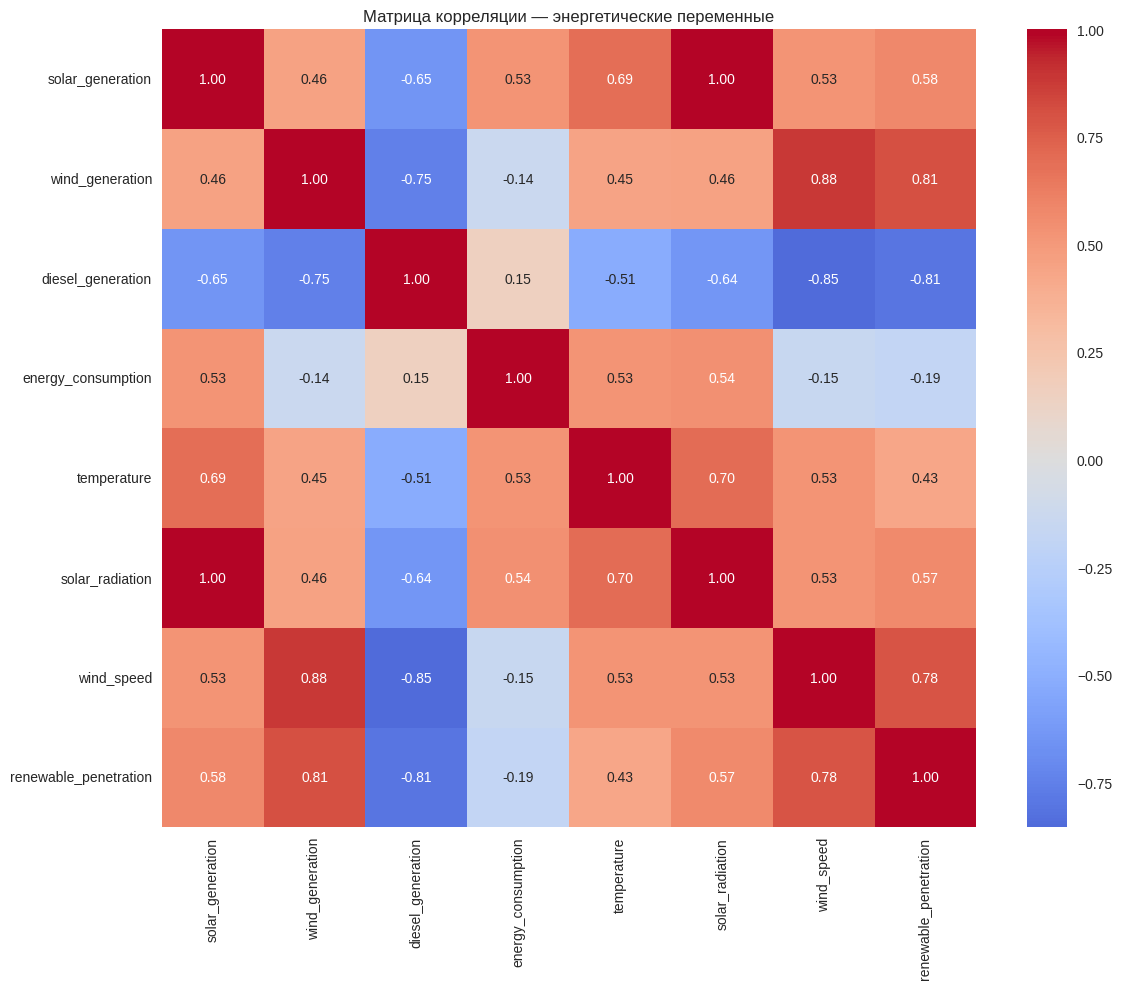

In [ ]:
# Корреляционный анализ
correlation_matrix = microgrid_data[['solar_generation', 'wind_generation', 'diesel_generation',
                                  'energy_consumption', 'temperature', 'solar_radiation', 'wind_speed',
                                  'renewable_penetration']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляции — энергетические переменные')
plt.tight_layout()
plt.show()

In [ ]:
# Статистика данных
print("Статистика данных микросетей:")
print(microgrid_data[['energy_consumption', 'solar_generation', 'wind_generation',
                      'diesel_generation', 'grid_voltage']].describe())

Статистика данных микросетей:
       energy_consumption  solar_generation  wind_generation  \
count         4320.000000       4320.000000      4320.000000   
mean            60.030079         30.032673        15.546595   
std             24.858399         41.576504        20.125674   
min              6.248121        -33.929172         0.000000   
25%             41.948838         -0.717617         0.000000   
50%             59.705119         11.002444         5.524170   
75%             73.896254         60.988036        26.182256   
max            128.814972        145.333218       106.375027   

       diesel_generation  grid_voltage  
count        4320.000000   4320.000000  
mean           25.518285    230.416978  
std            22.778930     10.256825  
min             0.000000    213.143352  
25%             0.000000    221.262048  
50%            27.087638    228.550147  
75%            50.000000    239.342371  
max            50.000000    254.184978  


### Модуль 3: Подготовка данных для LSTM. Подготовка временных рядов для прогнозирования энергопотребления

In [ ]:
def prepare_lstm_data_microgrid(data, target_column='energy_consumption',
                               lookback=72, forecast_horizon=24):
    """
    Подготовка данных микросетей для LSTM
    lookback: 72 часа (3 дня) исторических данных
    forecast_horizon: 24 часа (1 день) прогноза
    """
    # Выбор признаков для модели
    feature_columns = [
        'energy_consumption', 'solar_generation', 'wind_generation',
        'diesel_generation', 'grid_voltage', 'temperature',
        'solar_radiation', 'wind_speed', 'hour', 'day_of_week',
        'is_weekend', 'total_renewable_generation', 'energy_balance',
        'renewable_penetration'
    ]

    features = data[feature_columns].values
    target = data[target_column].values

    # Нормализация данных
    scaler_features = MinMaxScaler(feature_range=(0, 1))
    scaler_target = MinMaxScaler(feature_range=(0, 1))

    features_scaled = scaler_features.fit_transform(features)
    target_scaled = scaler_target.fit_transform(target.reshape(-1, 1))

    # Создание последовательностей
    X, y = [], []

    for i in range(len(features_scaled) - lookback - forecast_horizon):
        # Признаки: исторические данные
        X.append(features_scaled[i:(i + lookback)])
        # Целевая переменная: будущее потребление
        y.append(target_scaled[i + lookback:i + lookback + forecast_horizon, 0])

    return (np.array(X), np.array(y),
            scaler_features, scaler_target,
            feature_columns)

In [ ]:
# Подготовка данных для LSTM
LOOKBACK = 72  # 3 дня исторических данных
FORECAST_HORIZON = 24  # Прогноз на 24 часа вперед
TARGET_COLUMN = 'energy_consumption'

print("Подготовка данных для LSTM...")
X, y, scaler_features, scaler_target, feature_columns = prepare_lstm_data_microgrid(
    microgrid_data, TARGET_COLUMN, LOOKBACK, FORECAST_HORIZON
)

print(f"Форма данных:")
print(f"X: {X.shape}")  # [samples, lookback, features]
print(f"y: {y.shape}")  # [samples, forecast_horizon]
print(f"Количество признаков: {len(feature_columns)}")
print(f"Признаки: {feature_columns}")

Подготовка данных для LSTM...
Форма данных:
X: (4224, 72, 14)
y: (4224, 24)
Количество признаков: 14
Признаки: ['energy_consumption', 'solar_generation', 'wind_generation', 'diesel_generation', 'grid_voltage', 'temperature', 'solar_radiation', 'wind_speed', 'hour', 'day_of_week', 'is_weekend', 'total_renewable_generation', 'energy_balance', 'renewable_penetration']


In [ ]:
# Разделение на обучающую, валидационную и тестовую выборки
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, X_temp = X[:train_size], X[train_size:]
y_train, y_temp = y[:train_size], y[train_size:]

X_val, X_test = X_temp[:val_size], X_temp[val_size:]
y_val, y_test = y_temp[:val_size], y_temp[val_size:]

print(f"Разделение данных:")
print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Валидационная выборка: {X_val.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")

Разделение данных:
Обучающая выборка: 2956 samples
Валидационная выборка: 633 samples
Тестовая выборка: 635 samples


### Модуль 4: Построение модели LSTM для микросетей. Создание архитектуры LSTM для прогнозирования энергопотребления

In [ ]:
def build_microgrid_lstm_model(input_shape, output_steps=24, units=128, dropout_rate=0.3, learning_rate=0.001):
    """
    Построение модели LSTM для прогнозирования энергопотребления в микросетях
    """
    model = Sequential([
        # Первый LSTM слой
        LSTM(units=units,
             return_sequences=True,
             input_shape=input_shape,
             dropout=dropout_rate,
             recurrent_dropout=dropout_rate/2,
             kernel_initializer='glorot_uniform'),

        BatchNormalization(),

        # Второй LSTM слой
        LSTM(units=units//2,
             return_sequences=True,
             dropout=dropout_rate,
             recurrent_dropout=dropout_rate/2),

        BatchNormalization(),

        # Третий LSTM слой
        LSTM(units=units//4,
             return_sequences=False,
             dropout=dropout_rate,
             recurrent_dropout=dropout_rate/2),

        BatchNormalization(),

        Dropout(dropout_rate),

        # Полносвязные слои
        Dense(units=64, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(dropout_rate/2),

        Dense(units=32, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(dropout_rate/3),

        # Выходной слой для multi-step прогнозирования
        Dense(units=output_steps, activation='linear')
    ])

    # Компиляция модели
    model.compile(
        optimizer=Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999),
        loss='mse',
        metrics=['mae', 'mse']
    )

    return model

In [ ]:
# Построение модели
input_shape = (X_train.shape[1], X_train.shape[2])  # (lookback, n_features)

print("Построение модели LSTM для микросетей...")
model = build_microgrid_lstm_model(
    input_shape=input_shape,
    output_steps=FORECAST_HORIZON,
    units=128,
    dropout_rate=0.3,
    learning_rate=0.001
)

# Вывод архитектуры
model.summary()

Построение модели LSTM для микросетей...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 128)        │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 72, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 72, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,304 (551.97 KB)

 Trainable params: 140,664 (549.47 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Callbacks для обучения
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

print("Модель LSTM успешно построена!")

Модель LSTM успешно построена!


### Модуль 5: Обучение модели, Обучение LSTM на данных микросетей

In [ ]:
# Параметры обучения
EPOCHS = 200
BATCH_SIZE = 32

print("Начало обучения модели...")
print(f"Эпохи: {EPOCHS}")
print(f"Размер батча: {BATCH_SIZE}")

Начало обучения модели...
Эпохи: 200
Размер батча: 32


In [ ]:
# Обучение модели
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
    shuffle=False  # Важно для временных рядов
)

Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 67s 568ms/step - loss: 1.0558 - mae: 0.8072 - mse: 1.0558 - val_loss: 0.2759 - val_mae: 0.4553 - val_mse: 0.2759 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 338ms/step - loss: 0.3566 - mae: 0.4712 - mse: 0.3566 - val_loss: 0.1796 - val_mae: 0.3615 - val_mse: 0.1796 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 338ms/step - loss: 0.1697 - mae: 0.3228 - mse: 0.1697 - val_loss: 0.1272 - val_mae: 0.2970 - val_mse: 0.1272 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 42s 352ms/step - loss: 0.0995 - mae: 0.2462 - mse: 0.0995 - val_loss: 0.0875 - val_mae: 0.2441 - val_mse: 0.0875 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 345ms/step - loss: 0.0697 - mae: 0.2062 - mse: 0.0697 - val_loss: 0.0821 - val_mae: 0.2359 - val_mse: 0.0821 - learning_rate: 0.0010
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 331ms/step - loss: 0.0557 - mae: 0.1845 - mse: 0.0557 - val_loss: 0.0744 - va

In [ ]:
# Сохранение модели
model.save('microgrid_lstm_model.h5')
print("Модель сохранена как 'microgrid_lstm_model.h5'")

Модель сохранена как 'microgrid_lstm_model.h5'


In [ ]:
# Сохранение scalers для будущего использования
import joblib
joblib.dump(scaler_features, 'scaler_features.pkl')
joblib.dump(scaler_target, 'scaler_target.pkl')
print("Scalers сохранены")

Scalers сохранены


### Модуль 6: Оценка и визуализация результатов. Анализ производительности модели

In [ ]:
# Оценка на тестовой выборке
print("Оценка на тестовой выборке...")
test_loss, test_mae, test_mse = model.evaluate(X_test, y_test, verbose=0)

print(f"Результаты на тестовой выборке:")
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}")

Оценка на тестовой выборке...
Результаты на тестовой выборке:
Test Loss (MSE): 0.0738
Test MAE: 0.2215
Test MSE: 0.0738


In [ ]:
# Прогнозы на тестовой выборке
y_pred = model.predict(X_test)

# Денормализация прогнозов и фактических значений
y_test_actual = scaler_target.inverse_transform(y_test)
y_pred_actual = scaler_target.inverse_transform(y_pred)

# Расчет метрик в исходном масштабе
mse_actual = mean_squared_error(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mse_actual)
mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"\nМетрики в исходном масштабе (кВт):")
print(f"MSE: {mse_actual:.2f}")
print(f"RMSE: {rmse_actual:.2f}")
print(f"MAE: {mae_actual:.2f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step

Метрики в исходном масштабе (кВт):
MSE: 1109.09
RMSE: 33.30
MAE: 27.15


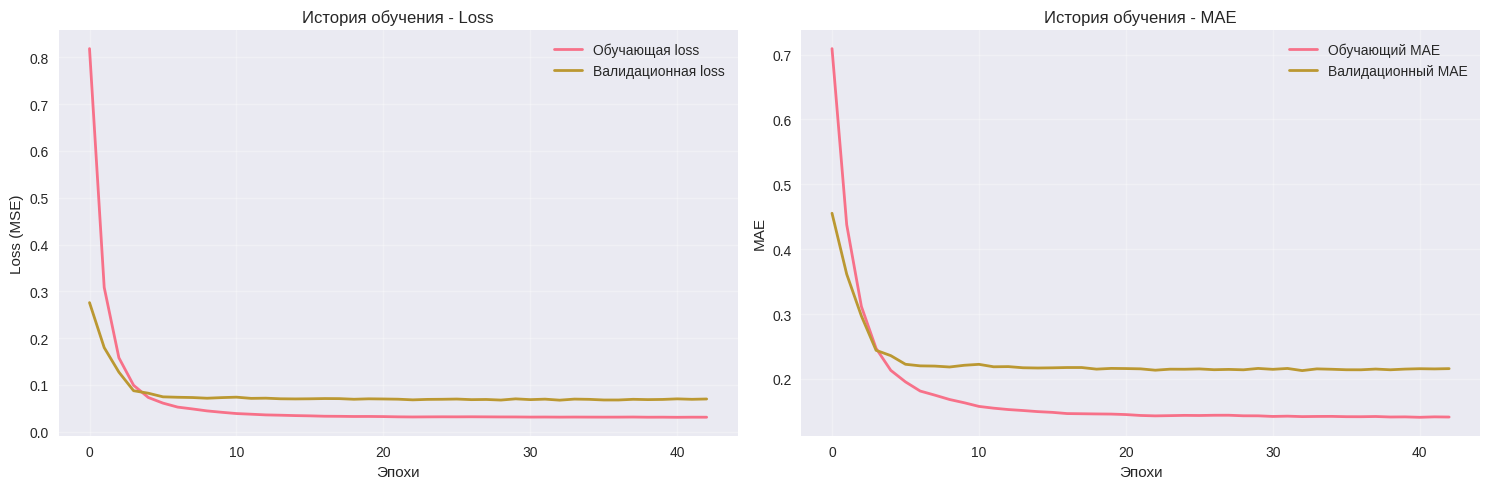

In [ ]:
# Визуализация истории обучения
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Обучающая loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Валидационная loss', linewidth=2)
plt.title('История обучения - Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Обучающий MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Валидационный MAE', linewidth=2)
plt.title('История обучения - MAE')
plt.xlabel('Эпохи')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Визуализация прогнозов...


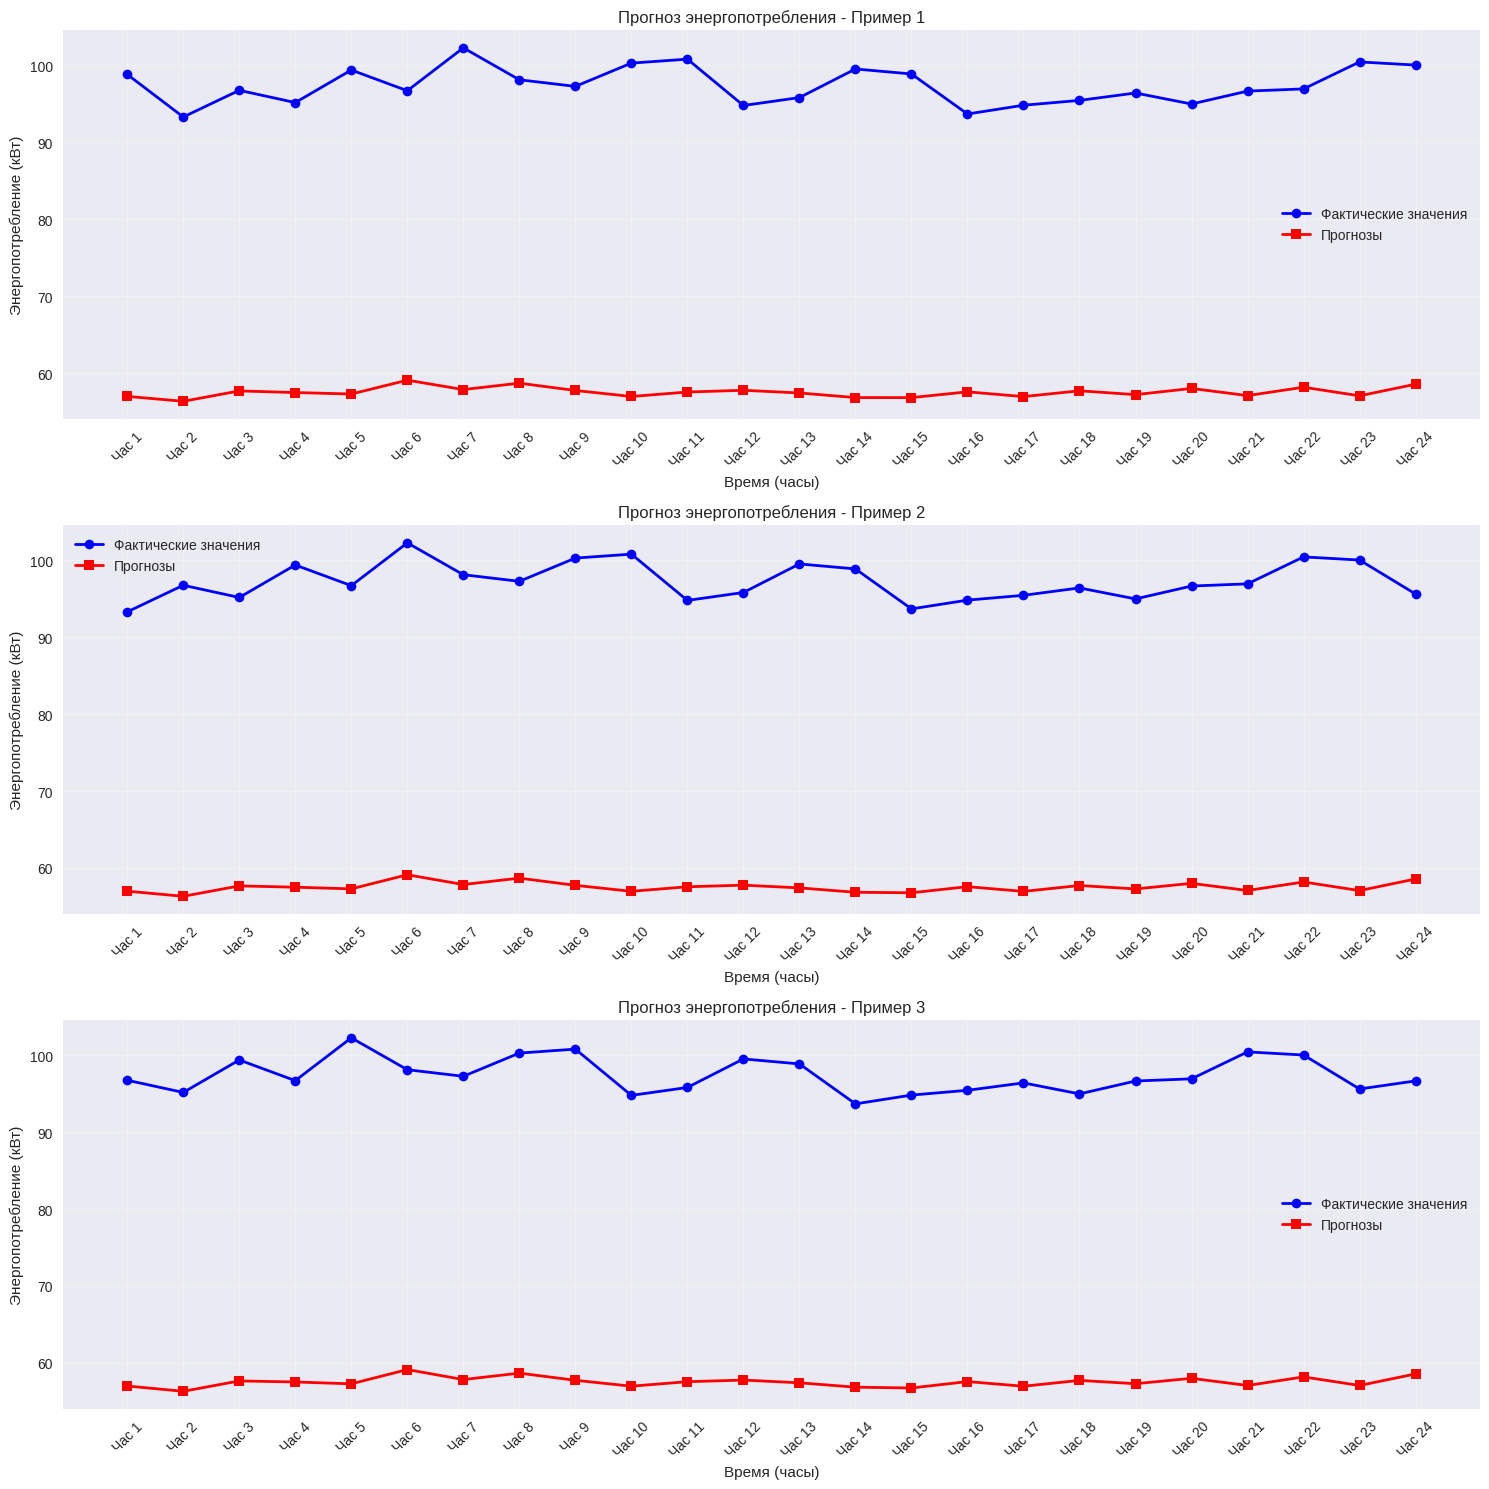

In [ ]:
# Визуализация прогнозов
def plot_predictions(actual, predicted, num_samples=3, days=3):
    """
    Визуализация прогнозов модели
    """
    hours = days * 24
    samples_to_plot = min(num_samples, len(actual))

    fig, axes = plt.subplots(samples_to_plot, 1, figsize=(15, 5 * samples_to_plot))

    if samples_to_plot == 1:
        axes = [axes]

    for i in range(samples_to_plot):
        ax = axes[i]

        # Фактические значения
        actual_plot = actual[i][:hours]
        # Прогнозируемые значения
        predicted_plot = predicted[i][:hours]

        time_steps = range(len(actual_plot))

        ax.plot(time_steps, actual_plot, 'b-', label='Фактические значения', linewidth=2, marker='o')
        ax.plot(time_steps, predicted_plot, 'r-', label='Прогнозы', linewidth=2, marker='s')

        ax.set_title(f'Прогноз энергопотребления - Пример {i+1}')
        ax.set_xlabel('Время (часы)')
        ax.set_ylabel('Энергопотребление (кВт)')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Добавление меток времени
        hours_labels = [f'Час {j+1}' for j in range(hours)]
        ax.set_xticks(range(hours))
        ax.set_xticklabels(hours_labels[:hours], rotation=45)

    plt.tight_layout()
    plt.show()

# Визуализация нескольких примеров прогнозов
print("Визуализация прогнозов...")
plot_predictions(y_test_actual, y_pred_actual, num_samples=3, days=1)

### Модуль 7: Прогнозирование и развертывание. Использование модели для реальных прогнозов

In [ ]:
class MicrogridPredictor:
    """
    Класс для прогнозирования энергопотребления в микросетях
    """

    def __init__(self, model, scaler_features, scaler_target, feature_columns, lookback=72):
        self.model = model
        self.scaler_features = scaler_features
        self.scaler_target = scaler_target
        self.feature_columns = feature_columns
        self.lookback = lookback
        self.history = None

    def update_history(self, new_data):
        """
        Обновление исторических данных
        """
        if self.history is None:
            self.history = new_data.copy()
        else:
            self.history = pd.concat([self.history, new_data], ignore_index=True)
            # Сохранение только последних lookback * 2 точек
            if len(self.history) > self.lookback * 2:
                self.history = self.history.tail(self.lookback * 2)

    def prepare_input(self, current_data):
        """
        Подготовка входных данных для прогноза
        """
        # Создание признаков
        current_data = create_microgrid_features(current_data)

        # Выбор нужных признаков
        features = current_data[self.feature_columns].values

        # Нормализация
        features_scaled = self.scaler_features.transform(features)

        # Создание последовательности
        if len(features_scaled) >= self.lookback:
            input_sequence = features_scaled[-self.lookback:]
        else:
            # Дополнение нулями если данных недостаточно
            padding = np.zeros((self.lookback - len(features_scaled), len(self.feature_columns)))
            input_sequence = np.vstack([padding, features_scaled])

        return input_sequence.reshape(1, self.lookback, len(self.feature_columns))

    def predict(self, current_data):
        """
        Прогноз энергопотребления на следующие 24 часа
        """
        input_sequence = self.prepare_input(current_data)
        prediction_scaled = self.model.predict(input_sequence, verbose=0)
        prediction_actual = self.scaler_target.inverse_transform(prediction_scaled)

        return prediction_actual[0]

In [ ]:
# Пример использования прогнозирующей системы
print("Создание системы прогнозирования...")
predictor = MicrogridPredictor(
    model=model,
    scaler_features=scaler_features,
    scaler_target=scaler_target,
    feature_columns=feature_columns,
    lookback=LOOKBACK
)

Создание системы прогнозирования...


In [ ]:
# Генерация тестовых данных для демонстрации
print("Генерация демонстрационных данных...")
demo_data = generate_microgrid_data(days=7, samples_per_day=24)
demo_data = create_microgrid_features(demo_data)

# Прогноз на основе последних данных
last_week_data = demo_data.tail(LOOKBACK)
prediction = predictor.predict(last_week_data)

print("Прогноз энергопотребления на следующие 24 часа:")
for hour, consumption in enumerate(prediction, 1):
    print(f"Час {hour:2d}: {consumption:6.2f} кВт")

Генерация демонстрационных данных...
Прогноз энергопотребления на следующие 24 часа:
Час  1:  58.05 кВт
Час  2:  58.08 кВт
Час  3:  57.12 кВт
Час  4:  57.54 кВт
Час  5:  57.68 кВт
Час  6:  58.16 кВт
Час  7:  57.88 кВт
Час  8:  57.39 кВт
Час  9:  57.44 кВт
Час 10:  57.87 кВт
Час 11:  57.82 кВт
Час 12:  58.04 кВт
Час 13:  57.78 кВт
Час 14:  57.73 кВт
Час 15:  58.08 кВт
Час 16:  57.34 кВт
Час 17:  58.10 кВт
Час 18:  58.01 кВт
Час 19:  57.40 кВт
Час 20:  57.92 кВт
Час 21:  57.75 кВт
Час 22:  57.37 кВт
Час 23:  58.01 кВт
Час 24:  58.03 кВт


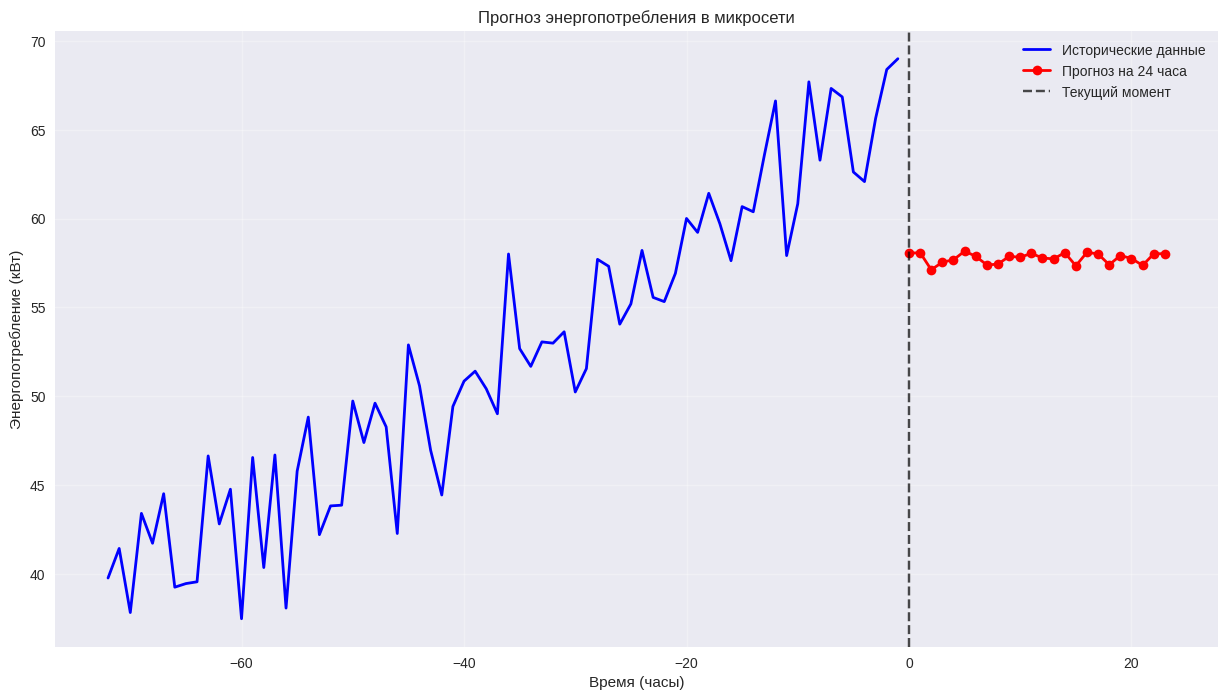

In [ ]:
# Визуализация прогноза
plt.figure(figsize=(15, 8))

# Исторические данные
historical_hours = range(-len(last_week_data), 0)
historical_consumption = last_week_data['energy_consumption'].values

# Прогноз
forecast_hours = range(len(prediction))
forecast_consumption = prediction

plt.plot(historical_hours, historical_consumption, 'b-',
         label='Исторические данные', linewidth=2)
plt.plot(forecast_hours, forecast_consumption, 'r-',
         label='Прогноз на 24 часа', linewidth=2, marker='o')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='Текущий момент')

plt.title('Прогноз энергопотребления в микросети')
plt.xlabel('Время (часы)')
plt.ylabel('Энергопотребление (кВт)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Анализ эффективности для планирования генерации
def analyze_generation_planning(prediction, renewable_capacity):
    """
    Анализ потребности в дизельной генерации на основе прогноза
    """
    avg_consumption = np.mean(prediction)
    max_consumption = np.max(prediction)
    min_consumption = np.min(prediction)

    # Оценка покрытия возобновляемыми источниками
    # (упрощенная модель - в реальности нужны прогнозы погоды)
    estimated_solar = renewable_capacity['solar'] * 0.6  # Средняя эффективность
    estimated_wind = renewable_capacity['wind'] * 0.35   # Средний коэффициент использования

    total_renewable = estimated_solar + estimated_wind
    diesel_needed = max(0, avg_consumption - total_renewable)

    print("\nАнализ планирования генерации:")
    print(f"Среднее потребление: {avg_consumption:.2f} кВт")
    print(f"Пиковое потребление: {max_consumption:.2f} кВт")
    print(f"Минимальное потребление: {min_consumption:.2f} кВт")
    print(f"Ожидаемая возобновляемая генерация: {total_renewable:.2f} кВт")
    print(f"Необходимая дизельная генерация: {diesel_needed:.2f} кВт")

    if diesel_needed > 0:
        print("⚠️  Требуется дизельная генерация для покрытия нагрузки")
    else:
        print("✅ Возобновляемых источников достаточно для покрытия нагрузки")

    return diesel_needed

# Пример анализа
renewable_capacity = {'solar': 80, 'wind': 30}  # кВт установленной мощности
diesel_need = analyze_generation_planning(prediction, renewable_capacity)


Анализ планирования генерации:
Среднее потребление: 57.77 кВт
Пиковое потребление: 58.16 кВт
Минимальное потребление: 57.12 кВт
Ожидаемая возобновляемая генерация: 58.50 кВт
Необходимая дизельная генерация: 0.00 кВт
✅ Возобновляемых источников достаточно для покрытия нагрузки


In [ ]:
# Финальный отчет
print("\n" + "="*60)
print("ФИНАЛЬНЫЙ ОТЧЕТ: СИСТЕМА ПРОГНОЗИРОВАНИЯ МИКРОСЕТИ")
print("="*60)
print(f"Качество прогноза (MAE): {mae_actual:.2f} кВт")
print(f"Точность прогноза: {100 * (1 - mae_actual/np.mean(y_test_actual)):.1f}%")
print(f"Горизонт прогнозирования: {FORECAST_HORIZON} часов")
print(f"Глубина исторических данных: {LOOKBACK} часов")
print(f"Количество используемых признаков: {len(feature_columns)}")
print("="*60)


ФИНАЛЬНЫЙ ОТЧЕТ: СИСТЕМА ПРОГНОЗИРОВАНИЯ МИКРОСЕТИ
Качество прогноза (MAE): 27.15 кВт
Точность прогноза: 63.0%
Горизонт прогнозирования: 24 часов
Глубина исторических данных: 72 часов
Количество используемых признаков: 14


## Модуль 2: Расширенный Feature Engineering для Микросетей

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

# Настройки для воспроизводимости
np.random.seed(42)

In [ ]:
def generate_enhanced_microgrid_data(days=365, samples_per_day=24):
    """
    Генерация расширенных данных микросетей с учетом специфики Западной Африки
    """
    total_samples = days * samples_per_day
    t = np.linspace(0, days, total_samples)

    # Базовые климатические параметры
    # Солнечная радиация с учетом сезона дождей
    rainy_season = np.sin(2 * np.pi * (t - 150) / 365)  # Сезон дождей июнь-сентябрь
    rain_effect = np.maximum(0, rainy_season * 0.6)  # Снижение солнечной активности

    solar_radiation = (
        np.sin(2 * np.pi * t / 24) *  # Суточный цикл
        (1 + 0.3 * np.sin(2 * np.pi * t / 365)) *  # Сезонные колебания
        (1 - rain_effect) *  # Влияние сезона дождей
        np.maximum(0, np.sin(np.pi * (t % 24) / 12)) +  # Ночью нет солнца
        0.1 * np.random.normal(size=total_samples)
    )

    # Скорость ветра с муссонными паттернами
    monsoon_effect = 0.3 * np.sin(2 * np.pi * (t - 180) / 365)  # Муссонные ветра
    wind_speed = (
        3 + 2 * np.sin(2 * np.pi * t / 24 + np.pi/4) +  # Суточные колебания
        1.5 * np.sin(2 * np.pi * t / 365) +  # Сезонные изменения
        monsoon_effect +  # Муссонный эффект
        0.5 * np.random.normal(size=total_samples)
    )

    # Температура и влажность
    temperature = (
        28 + 8 * np.sin(2 * np.pi * t / 24) +  # Суточные колебания
        5 * np.sin(2 * np.pi * t / 365 - np.pi/2) +  # Сезонные изменения
        2 * rain_effect * (-3) +  # Снижение температуры во время дождей
        0.5 * np.random.normal(size=total_samples)
    )

    humidity = (
        60 + 20 * np.sin(2 * np.pi * t / 24) +  # Суточные колебания
        15 * rain_effect +  # Повышение влажности в дождливый сезон
        5 * np.random.normal(size=total_samples)
    )

    # Социально-экономические факторы
    # Дни недели и праздничные дни
    day_of_year = (t.astype(int) % 365)
    weekend_effect = ((day_of_year % 7) >= 5).astype(float) * 0.8  # Выходные

    # Праздничные дни (условные даты)
    holidays = np.isin(day_of_year % 365, [0, 15, 75, 120, 180, 245, 300, 360])
    holiday_effect = holidays.astype(float) * 1.2

    # Экономическая активность (рост в течение года)
    economic_growth = 1 + 0.001 * t  # Постепенный рост потребления

    # Паттерны потребления энергии
    morning_peak = 0.6 * np.exp(-0.5 * ((t % 24) - 8)**2)  # Утренний пик 8:00
    evening_peak = 0.8 * np.exp(-0.3 * ((t % 24) - 19)**2)  # Вечерний пик 19:00

    base_consumption = (
        50 +
        25 * np.sin(2 * np.pi * t / 24 - np.pi/2) +  # Базовый суточный цикл
        15 * morning_peak +  # Утренний пик
        20 * evening_peak +  # Вечерний пик
        10 * weekend_effect +  # Выходные
        15 * holiday_effect +  # Праздники
        8 * np.maximum(0, temperature - 30) +  # Кондиционирование
        5 * economic_growth +  # Экономический рост
        3 * np.random.normal(size=total_samples)
    )

    # Генерация солнечной энергии
    panel_efficiency = 0.18 * (1 - 0.004 * (temperature - 25))  # Температурная коррекция
    solar_generation = (
        solar_radiation * 500 * panel_efficiency *  # Мощность системы 500 кв.м.
        (1 - 0.001 * humidity)  # Влияние влажности на эффективность
    )

    # Генерация ветровой энергии
    wind_power_curve = np.piecewise(wind_speed,
                                   [wind_speed < 3, (wind_speed >= 3) & (wind_speed <= 25), wind_speed > 25],
                                   [0, lambda x: (x - 3)**2 * 2, 0])  # Квадратичная зависимость

    wind_generation = wind_power_curve * 10  # 10 ветряных турбин

    # Дизельная генерация
    energy_deficit = np.maximum(0, base_consumption - solar_generation - wind_generation)
    diesel_efficiency = 0.35 * (1 - 0.01 * (temperature - 25))  # Влияние температуры на КПД
    diesel_generation = np.minimum(80, energy_deficit / diesel_efficiency)  # Максимальная мощность 80 кВт

    # Параметры сети
    grid_voltage = (
        230 +
        8 * np.sin(2 * np.pi * t / 24) +  # Суточные колебания
        5 * (base_consumption - np.mean(base_consumption)) / np.std(base_consumption) +  # Влияние нагрузки
        3 * np.random.normal(size=total_samples)
    )

    # Частота сети
    grid_frequency = (
        50 +
        0.1 * np.sin(2 * np.pi * t / 24) +  # Суточные колебания
        0.2 * (energy_deficit - np.mean(energy_deficit)) / np.std(energy_deficit) +  # Влияние дефицита
        0.05 * np.random.normal(size=total_samples)
    )

    # Создание DataFrame
    data = pd.DataFrame({
        'timestamp': pd.date_range(start='2023-01-01', periods=total_samples, freq='H'),
        'solar_radiation': solar_radiation,
        'wind_speed': wind_speed,
        'temperature': temperature,
        'humidity': humidity,
        'energy_consumption': base_consumption,
        'solar_generation': solar_generation,
        'wind_generation': wind_generation,
        'diesel_generation': diesel_generation,
        'grid_voltage': grid_voltage,
        'grid_frequency': grid_frequency,
        'energy_deficit': energy_deficit,
        'rain_effect': rain_effect,
        'monsoon_effect': monsoon_effect
    })

    return data

In [ ]:
def create_advanced_features(data):
    """
    Создание расширенных признаков для микросетей
    """
    df = data.copy()

    # === ВРЕМЕННЫЕ ПРИЗНАКИ ===
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['day_of_month'] = df['timestamp'].dt.day
    df['month'] = df['timestamp'].dt.month
    df['quarter'] = df['timestamp'].dt.quarter
    df['day_of_year'] = df['timestamp'].dt.dayofyear

    # Циклические признаки времени
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Признаки рабочих/выходных дней
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_holiday'] = ((df['day_of_month'] == 1) | (df['day_of_month'] == 15)).astype(int)  # Условные праздники

    # === ТЕХНИЧЕСКИЕ ПРИЗНАКИ ===
    # Баланс энергии
    df['total_generation'] = df['solar_generation'] + df['wind_generation'] + df['diesel_generation']
    df['energy_balance'] = df['total_generation'] - df['energy_consumption']
    df['renewable_ratio'] = (df['solar_generation'] + df['wind_generation']) / (df['total_generation'] + 1e-5)
    df['diesel_dependency'] = df['diesel_generation'] / (df['total_generation'] + 1e-5)

    # Эффективность систем
    df['solar_efficiency'] = df['solar_generation'] / (df['solar_radiation'] + 1e-5)
    df['wind_efficiency'] = df['wind_generation'] / (df['wind_speed'] + 1e-5)

    # Стабильность сети
    df['voltage_deviation'] = np.abs(df['grid_voltage'] - 230)
    df['frequency_deviation'] = np.abs(df['grid_frequency'] - 50)
    df['grid_stability'] = 1 / (1 + df['voltage_deviation'] + df['frequency_deviation'])

    # === СТАТИСТИЧЕСКИЕ ПРИЗНАКИ ===
    # Скользящие статистики для потребления
    windows = [6, 12, 24, 168]  # 6ч, 12ч, 24ч, 1 неделя

    for window in windows:
        # Потребление
        df[f'consumption_ma_{window}h'] = df['energy_consumption'].rolling(window=window, min_periods=1).mean()
        df[f'consumption_std_{window}h'] = df['energy_consumption'].rolling(window=window, min_periods=1).std()
        df[f'consumption_min_{window}h'] = df['energy_consumption'].rolling(window=window, min_periods=1).min()
        df[f'consumption_max_{window}h'] = df['energy_consumption'].rolling(window=window, min_periods=1).max()

        # Генерация
        df[f'solar_ma_{window}h'] = df['solar_generation'].rolling(window=window, min_periods=1).mean()
        df[f'wind_ma_{window}h'] = df['wind_generation'].rolling(window=window, min_periods=1).mean()

    # Относительные изменения
    df['consumption_change_1h'] = df['energy_consumption'].pct_change(periods=1)
    df['consumption_change_24h'] = df['energy_consumption'].pct_change(periods=24)
    df['solar_change_1h'] = df['solar_generation'].pct_change(periods=1)

    # === ВЗАИМОДЕЙСТВИЯ ПРИЗНАКОВ ===
    # Взаимодействие погодных факторов
    df['temp_humidity_interaction'] = df['temperature'] * df['humidity']
    df['solar_wind_correlation'] = df['solar_radiation'] * df['wind_speed']

    # Временные взаимодействия
    df['weekend_evening'] = df['is_weekend'] * (df['hour'] >= 18).astype(int)
    df['morning_peak_hours'] = ((df['hour'] >= 7) & (df['hour'] <= 10)).astype(int)
    df['evening_peak_hours'] = ((df['hour'] >= 18) & (df['hour'] <= 22)).astype(int)

    # === ТРЕНДЫ И СЕЗОННОСТЬ ===
    # Детрендирование
    trend_24h = df['energy_consumption'].rolling(window=24, min_periods=1).mean()
    df['consumption_detrended_24h'] = df['energy_consumption'] - trend_24h

    # Сезонная декомпозиция (упрощенная)
    seasonal_24h = df.groupby('hour')['energy_consumption'].transform('mean')
    df['consumption_seasonal_24h'] = seasonal_24h
    df['consumption_residual'] = df['energy_consumption'] - seasonal_24h

    # === ПРОИЗВОДНЫЕ И ИНТЕГРАЛЫ ===
    # Производные (скорость изменения)
    df['consumption_derivative_1h'] = df['energy_consumption'].diff(1)
    df['consumption_derivative_6h'] = df['energy_consumption'].diff(6)

    # Интегральные признаки (накопленные значения)
    df['consumption_cumsum_24h'] = df['energy_consumption'].rolling(window=24, min_periods=1).sum()
    df['solar_cumsum_24h'] = df['solar_generation'].rolling(window=24, min_periods=1).sum()

    # === СПЕКТРАЛЬНЫЕ ПРИЗНАКИ ===
    # Быстрое преобразование Фурье (FFT) features
    for col in ['energy_consumption', 'solar_generation', 'wind_generation']:
        # Скользящее FFT
        for window in [24, 168]:
            fft_values = []
            for i in range(len(df)):
                if i >= window:
                    segment = df[col].iloc[i-window:i]
                    fft = np.fft.fft(segment - segment.mean())
                    magnitude = np.abs(fft)
                    # Основная частота
                    dominant_freq = np.argmax(magnitude[1:window//2]) + 1
                    fft_values.append(dominant_freq)
                else:
                    fft_values.append(np.nan)

            df[f'{col}_dominant_freq_{window}h'] = fft_values

    # Сглаживание Savitzky-Golay
    try:
        df['consumption_smooth'] = savgol_filter(df['energy_consumption'].fillna(method='bfill'),
                                                window_length=11, polyorder=3)
    except:
        df['consumption_smooth'] = df['energy_consumption']

    # === КЛАСТЕРНЫЕ ПРИЗНАКИ ===
    # Временные кластеры (утро, день, вечер, ночь)
    conditions = [
        (df['hour'] >= 0) & (df['hour'] < 6),
        (df['hour'] >= 6) & (df['hour'] < 12),
        (df['hour'] >= 12) & (df['hour'] < 18),
        (df['hour'] >= 18) & (df['hour'] < 24)
    ]
    choices = ['night', 'morning', 'afternoon', 'evening']
    df['time_cluster'] = np.select(conditions, choices, default='night')

    # Сезонные кластеры
    conditions_season = [
        df['month'].isin([12, 1, 2]),  # Сухой сезон
        df['month'].isin([3, 4, 5]),   # Жаркий сезон
        df['month'].isin([6, 7, 8, 9]), # Дождливый сезон
        df['month'].isin([10, 11])     # Переходный сезон
    ]
    choices_season = ['dry', 'hot', 'rainy', 'transition']
    df['season_cluster'] = np.select(conditions_season, choices_season, default='dry')

    # One-hot encoding для категориальных признаков
    df = pd.get_dummies(df, columns=['time_cluster', 'season_cluster'], prefix=['time', 'season'])

    # === ПРИЗНАКИ АНОМАЛИЙ ===
    # Z-score для обнаружения аномалий
    consumption_zscore = np.abs(stats.zscore(df['energy_consumption'].fillna(method='bfill')))
    df['consumption_anomaly'] = (consumption_zscore > 3).astype(int)

    # Внезапные изменения генерации
    solar_change_abs = np.abs(df['solar_generation'].diff(1))
    df['solar_ramp_event'] = (solar_change_abs > solar_change_abs.quantile(0.95)).astype(int)

    # Заполнение пропущенных значений
    df = df.fillna(method='bfill').fillna(method='ffill')

    # Удаление бесконечных значений
    df = df.replace([np.inf, -np.inf], np.nan).fillna(method='bfill')

    return df

In [ ]:
# Генерация и подготовка данных
print("Генерация расширенных данных микросетей...")
microgrid_data_enhanced = generate_enhanced_microgrid_data(days=180, samples_per_day=24)
microgrid_data_enhanced = create_advanced_features(microgrid_data_enhanced)

print("Расширенные данные сгенерированы:")
print(f"Размерность данных: {microgrid_data_enhanced.shape}")
print(f"Количество признаков: {len(microgrid_data_enhanced.columns)}")

Генерация расширенных данных микросетей...
Расширенные данные сгенерированы:
Размерность данных: (4320, 90)
Количество признаков: 90


In [ ]:
# Анализ созданных признаков
print("\nКатегории созданных признаков:")
feature_categories = {
    'Временные признаки': [col for col in microgrid_data_enhanced.columns if any(x in col for x in ['hour', 'day', 'month', 'quarter', 'weekend', 'holiday'])],
    'Технические признаки': [col for col in microgrid_data_enhanced.columns if any(x in col for x in ['generation', 'efficiency', 'voltage', 'frequency', 'stability'])],
    'Статистические признаки': [col for col in microgrid_data_enhanced.columns if any(x in col for x in ['ma_', 'std_', 'min_', 'max_', 'change_', 'derivative'])],
    'Взаимодействия': [col for col in microgrid_data_enhanced.columns if any(x in col for x in ['interaction', 'correlation', 'peak_', 'weekend_evening'])],
    'Спектральные признаки': [col for col in microgrid_data_enhanced.columns if 'freq' in col or 'smooth' in col],
    'Кластерные признаки': [col for col in microgrid_data_enhanced.columns if 'cluster' in col or 'time_' in col or 'season_' in col],
    'Признаки аномалий': [col for col in microgrid_data_enhanced.columns if 'anomaly' in col or 'ramp' in col]
}

for category, features in feature_categories.items():
    print(f"{category}: {len(features)} признаков")


Категории созданных признаков:
Временные признаки: 15 признаков
Технические признаки: 15 признаков
Статистические признаки: 29 признаков
Взаимодействия: 5 признаков
Спектральные признаки: 9 признаков
Кластерные признаки: 7 признаков
Признаки аномалий: 2 признаков


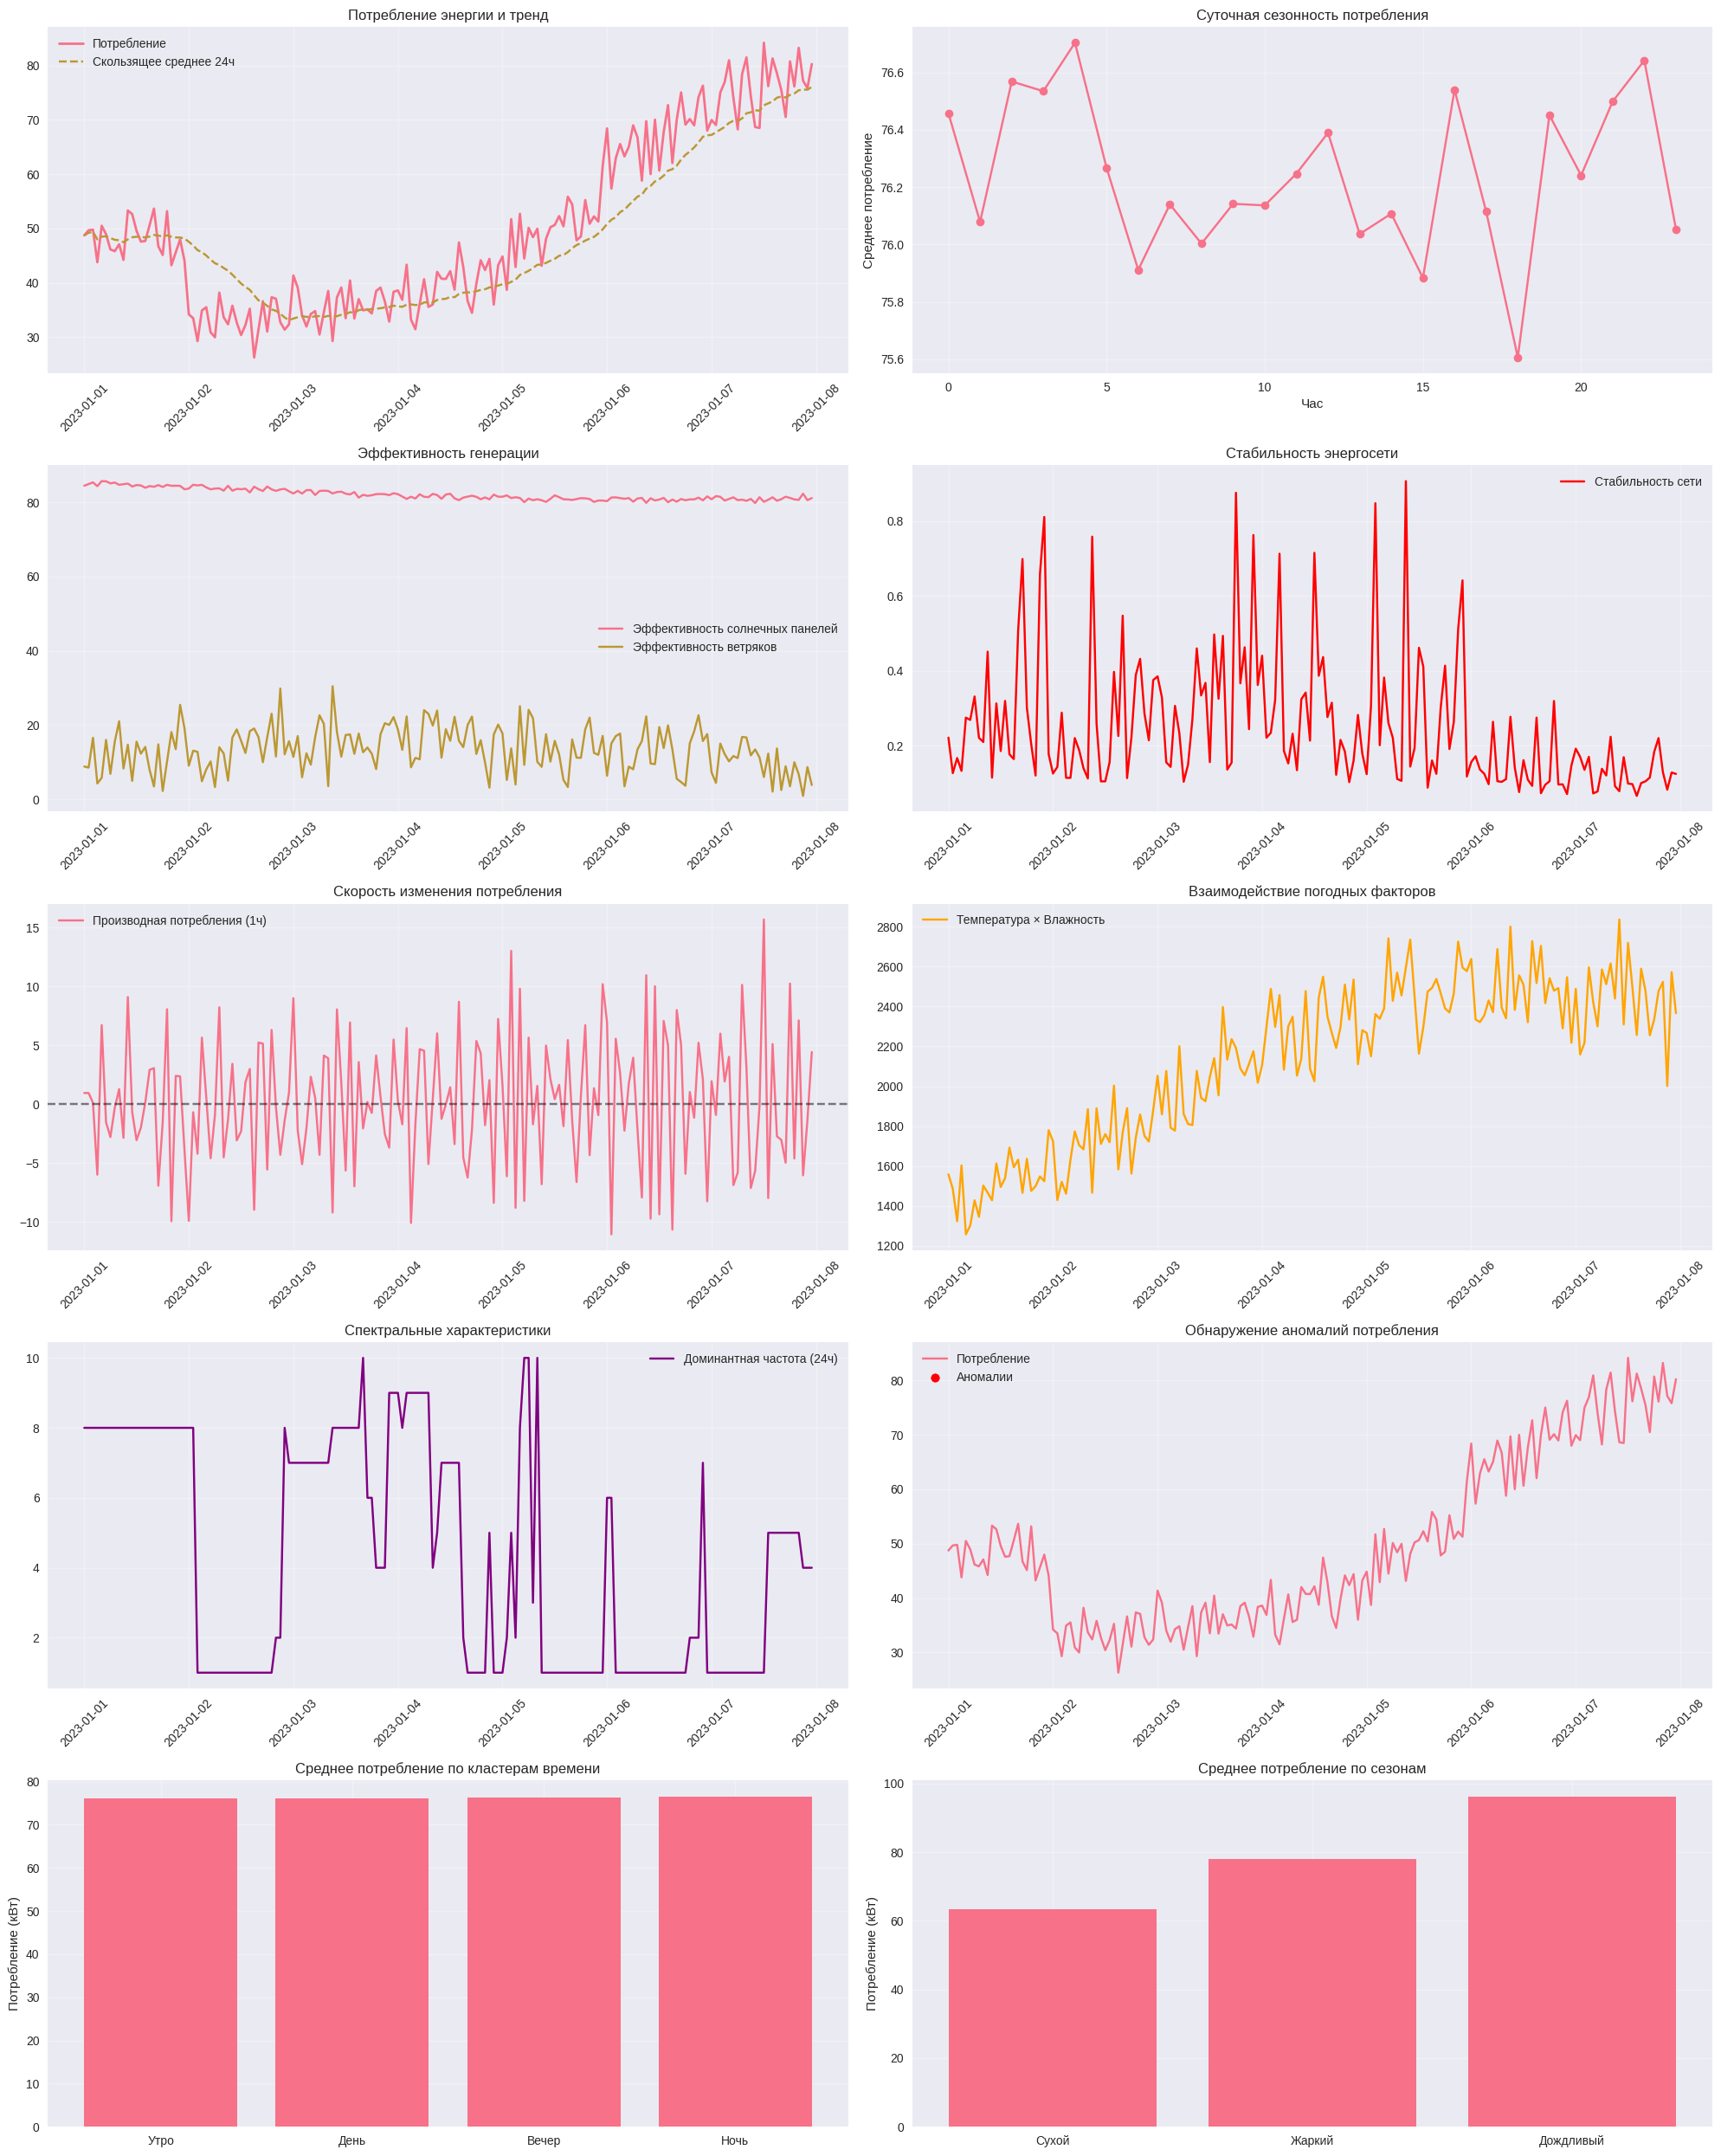

In [ ]:
# Визуализация расширенных признаков
plt.figure(figsize=(20, 25))

# 1. Временные паттерны
plt.subplot(5, 2, 1)
sample_data = microgrid_data_enhanced.head(168)  # 1 неделя
plt.plot(sample_data['timestamp'], sample_data['energy_consumption'], label='Потребление', linewidth=2)
plt.plot(sample_data['timestamp'], sample_data['consumption_ma_24h'], label='Скользящее среднее 24ч', linestyle='--')
plt.title('Потребление энергии и тренд')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Сезонность
plt.subplot(5, 2, 2)
hourly_pattern = microgrid_data_enhanced.groupby('hour')['energy_consumption'].mean()
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Суточная сезонность потребления')
plt.xlabel('Час')
plt.ylabel('Среднее потребление')
plt.grid(True, alpha=0.3)

# 3. Эффективность систем
plt.subplot(5, 2, 3)
plt.plot(sample_data['timestamp'], sample_data['solar_efficiency'], label='Эффективность солнечных панелей')
plt.plot(sample_data['timestamp'], sample_data['wind_efficiency'], label='Эффективность ветряков')
plt.title('Эффективность генерации')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Стабильность сети
plt.subplot(5, 2, 4)
plt.plot(sample_data['timestamp'], sample_data['grid_stability'], label='Стабильность сети', color='red')
plt.title('Стабильность энергосети')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Производные признаки
plt.subplot(5, 2, 5)
plt.plot(sample_data['timestamp'], sample_data['consumption_derivative_1h'], label='Производная потребления (1ч)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Скорость изменения потребления')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Взаимодействия признаков
plt.subplot(5, 2, 6)
plt.plot(sample_data['timestamp'], sample_data['temp_humidity_interaction'], label='Температура × Влажность', color='orange')
plt.title('Взаимодействие погодных факторов')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 7. Спектральные признаки
plt.subplot(5, 2, 7)
if 'energy_consumption_dominant_freq_24h' in microgrid_data_enhanced.columns:
    plt.plot(sample_data['timestamp'], sample_data['energy_consumption_dominant_freq_24h'].head(168),
             label='Доминантная частота (24ч)', color='purple')
    plt.title('Спектральные характеристики')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

# 8. Аномалии
plt.subplot(5, 2, 8)
anomaly_points = sample_data[sample_data['consumption_anomaly'] == 1]
plt.plot(sample_data['timestamp'], sample_data['energy_consumption'], label='Потребление')
plt.scatter(anomaly_points['timestamp'], anomaly_points['energy_consumption'],
           color='red', label='Аномалии', zorder=5)
plt.title('Обнаружение аномалий потребления')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Кластеры времени
plt.subplot(5, 2, 9)
time_cluster_means = []
for cluster in ['time_morning', 'time_afternoon', 'time_evening', 'time_night']:
    if cluster in microgrid_data_enhanced.columns:
        cluster_data = microgrid_data_enhanced[microgrid_data_enhanced[cluster] == 1]
        time_cluster_means.append(cluster_data['energy_consumption'].mean())

clusters = ['Утро', 'День', 'Вечер', 'Ночь']
plt.bar(clusters, time_cluster_means[:4])
plt.title('Среднее потребление по кластерам времени')
plt.ylabel('Потребление (кВт)')
plt.grid(True, alpha=0.3)

# 10. Сезонные кластеры
plt.subplot(5, 2, 10)
season_cluster_means = []
season_labels = []
for cluster, label in zip(['season_dry', 'season_hot', 'season_rainy', 'season_transition'],
                           ['Сухой', 'Жаркий', 'Дождливый', 'Переходный']):
    if cluster in microgrid_data_enhanced.columns:
        cluster_data = microgrid_data_enhanced[microgrid_data_enhanced[cluster] == 1]
        if not cluster_data.empty:
            season_cluster_means.append(cluster_data['energy_consumption'].mean())
            season_labels.append(label)

plt.bar(season_labels, season_cluster_means)
plt.title('Среднее потребление по сезонам')
plt.ylabel('Потребление (кВт)')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

Анализ корреляций...


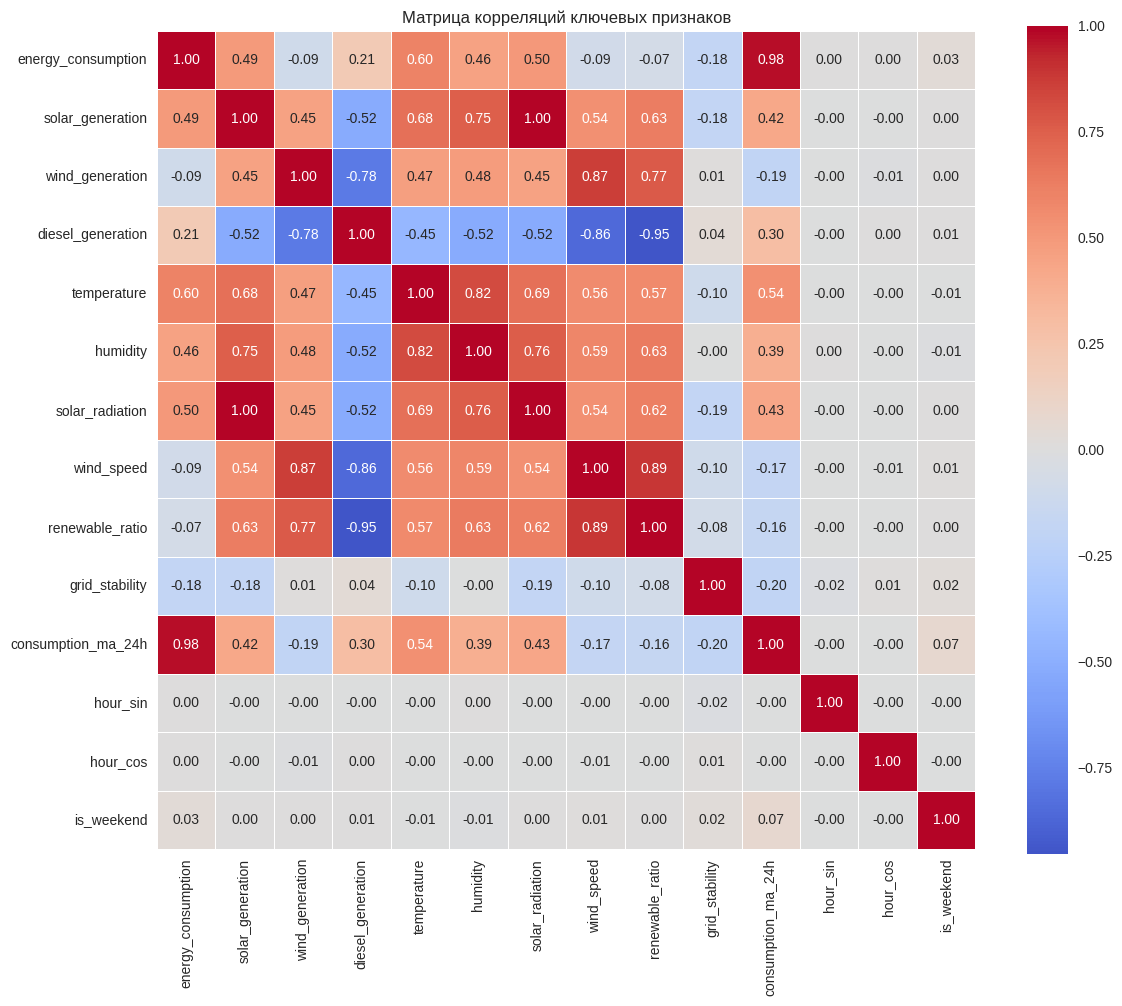

In [ ]:
# Корреляционный анализ
print("Анализ корреляций...")

# Выбор наиболее важных признаков для корреляционного анализа
important_features = [
    'energy_consumption', 'solar_generation', 'wind_generation', 'diesel_generation',
    'temperature', 'humidity', 'solar_radiation', 'wind_speed',
    'renewable_ratio', 'grid_stability', 'consumption_ma_24h',
    'hour_sin', 'hour_cos', 'is_weekend'
]

# Фильтрация существующих признаков
existing_features = [f for f in important_features if f in microgrid_data_enhanced.columns]
correlation_data = microgrid_data_enhanced[existing_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Матрица корреляций ключевых признаков')
plt.tight_layout()
plt.show()

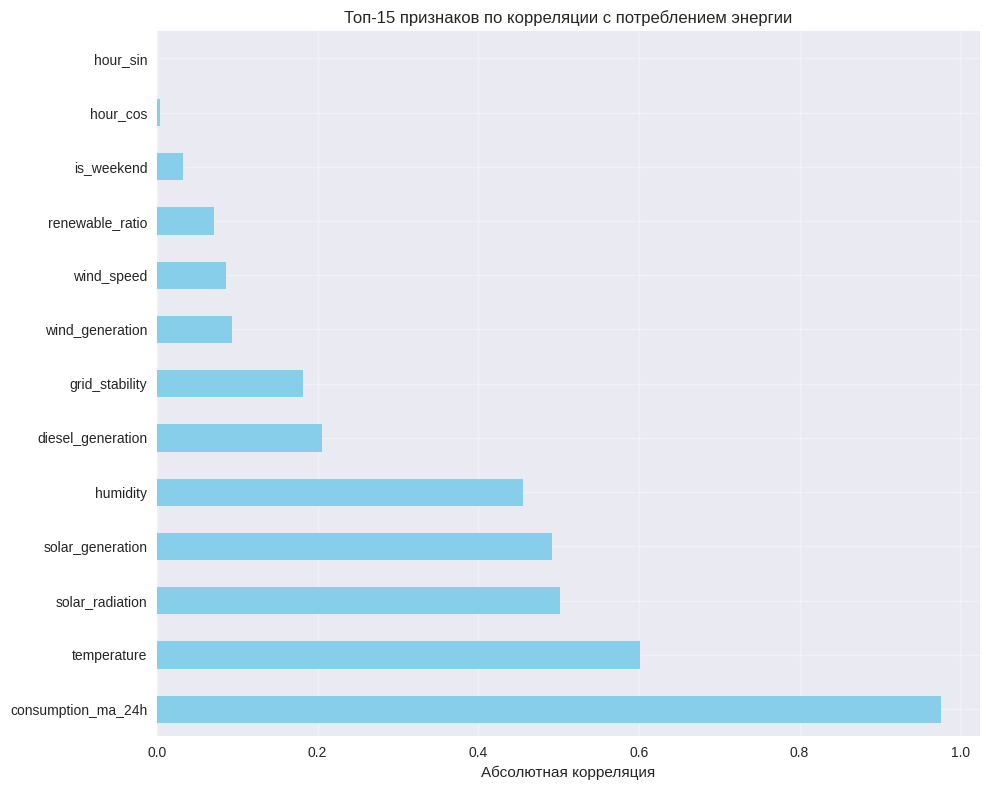

Топ-10 наиболее коррелированных признаков:
consumption_ma_24h: 0.976
temperature: 0.602
solar_radiation: 0.502
solar_generation: 0.492
humidity: 0.455
diesel_generation: 0.205
grid_stability: 0.182
wind_generation: 0.093
wind_speed: 0.086
renewable_ratio: 0.071


In [ ]:
# Анализ важности признаков (упрощенный)
target_correlations = correlation_data['energy_consumption'].drop('energy_consumption').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
target_correlations.head(15).plot(kind='barh', color='skyblue')
plt.title('Топ-15 признаков по корреляции с потреблением энергии')
plt.xlabel('Абсолютная корреляция')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Топ-10 наиболее коррелированных признаков:")
for feature, corr in target_correlations.head(10).items():
    print(f"{feature}: {corr:.3f}")

In [ ]:
# Сохранение расширенных данных
print("\nСохранение расширенных данных...")
microgrid_data_enhanced.to_csv('enhanced_microgrid_data.csv', index=False)
print("Данные сохранены в 'enhanced_microgrid_data.csv'")


Сохранение расширенных данных...
Данные сохранены в 'enhanced_microgrid_data.csv'


In [ ]:
# Финальная статистика
print("\n" + "="*60)
print("ФИНАЛЬНАЯ СТАТИСТИКА FEATURE ENGINEERING")
print("="*60)
print(f"Общее количество признаков: {len(microgrid_data_enhanced.columns)}")
print(f"Общее количество записей: {len(microgrid_data_enhanced)}")
print(f"Период данных: {microgrid_data_enhanced['timestamp'].min()} - {microgrid_data_enhanced['timestamp'].max()}")

# Анализ пропущенных значений
missing_values = microgrid_data_enhanced.isnull().sum()
missing_percentage = (missing_values / len(microgrid_data_enhanced)) * 100
print(f"\nПризнаки с пропущенными значениями (>0%):")
for col, missing in missing_percentage[missing_percentage > 0].items():
    print(f"  {col}: {missing:.2f}%")

print("="*60)


ФИНАЛЬНАЯ СТАТИСТИКА FEATURE ENGINEERING
Общее количество признаков: 90
Общее количество записей: 4320
Период данных: 2023-01-01 00:00:00 - 2023-06-29 23:00:00

Признаки с пропущенными значениями (>0%):


In [ ]:
class MicrogridController:
    def __init__(self):
        self.lstm_forecaster = LSTM_Model()
        self.ppo_controller = PPO_Agent()

    def optimize_operation(self, forecasts, grid_status):
        # Prévisions LSTM
        pv_pred, wind_pred, load_pred = self.lstm_forecaster.predict()

        # Décision PPO
        actions = self.ppo_controller.act({
            'soc': current_soc,
            'forecasts': [pv_pred, wind_pred, load_pred],
            'grid_available': grid_status,
            'fuel_level': diesel_level
        })

        return {
            'battery_power': actions['p_batt'],
            'grid_power': actions['p_grid'],
            'diesel_power': actions['p_diesel'],
            'flexible_loads': actions['load_control']
        }